In [ ]:
import os

import rasterio
import numpy as np
from rasterio.plot import show
from rasterio.plot import show_hist
from matplotlib import pyplot as plt
from scipy.ndimage import binary_erosion, binary_dilation

Joining bands

In [3]:
path_img = "./2016/"

bands_2016 = []

for root, dirs, files in os.walk(path_img, topdown=False):
   for name in files:
      img = rasterio.open(os.path.join(path_img, name))
      bands_2016.append(img.read())

In [4]:
path_img = "./2025/"

bands_2025 = []

for root, dirs, files in os.walk(path_img, topdown=False):
   for name in files:
      img = rasterio.open(os.path.join(path_img, name))
      bands_2025.append(img.read())

In [5]:
bands_2016 = np.concatenate(bands_2016)
bands_2025 = np.concatenate(bands_2025)

Picture research

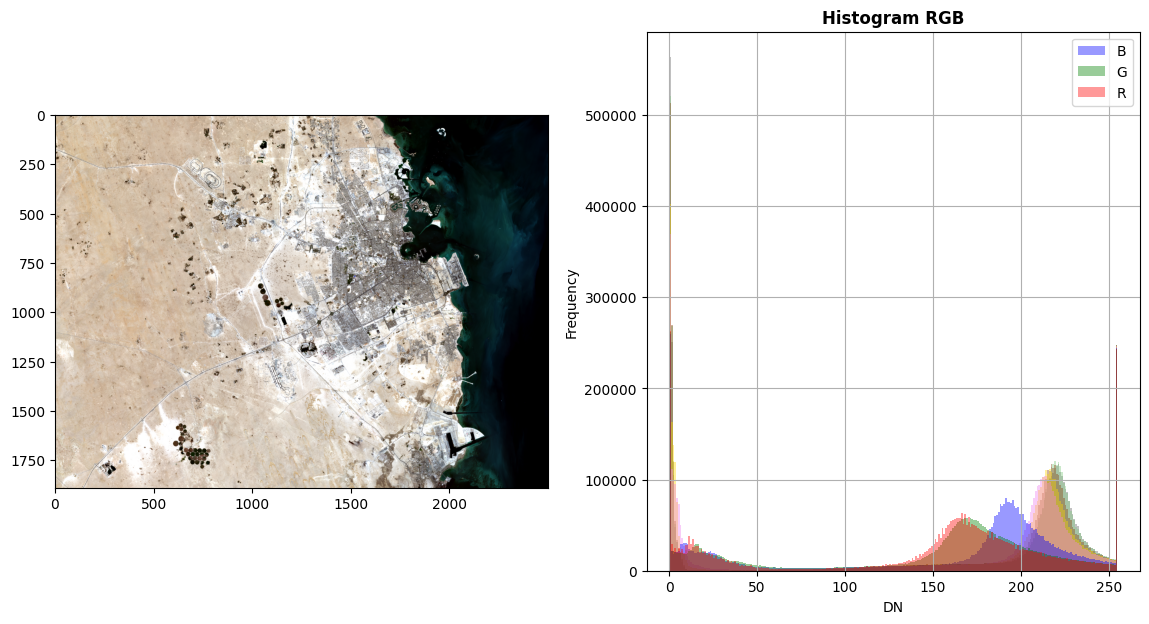

In [286]:
# 2016 high contrast
bands_8bit = []
for band in bands_2016[:8]:
    band = band.astype(np.float32)
    p1, p2 = np.percentile(band, (5,95))
    band = np.clip(band, p1, p2)
    band_8bit = (((band - p1))/(p2-p1))*255
    band_8bit = band_8bit.astype(np.uint8)
    bands_8bit.append(band_8bit)

bands_8bit_2016 = np.stack(bands_8bit, axis=0)
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(bands_8bit_2016[(3,2,1), :, :], ax=axrgb)
show_hist(bands_8bit_2016, bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)
plt.show()

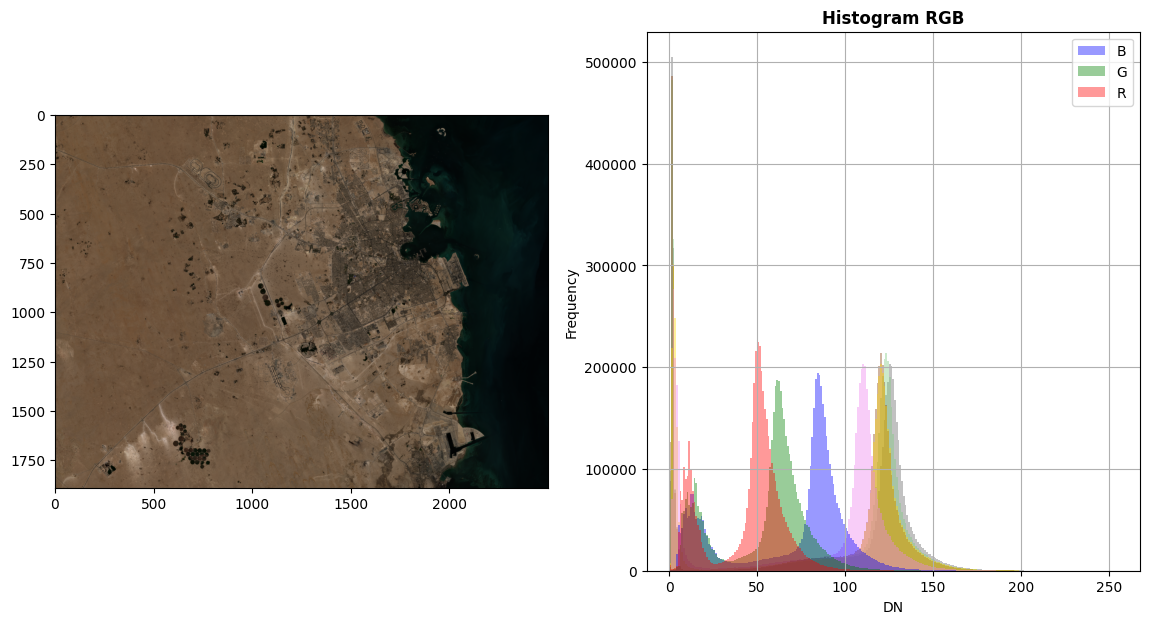

In [287]:
# 2016 normal

bands_8bit = []
for band in bands_2016[:8]:
    band = band.astype(np.float32)
    band = band/65535.0 * 255
    bands_8bit.append(band.astype(np.uint8))

bands_8bit_2016_N = np.stack(bands_8bit, axis=0)
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(bands_8bit_2016_N[(3,2,1), :, :], ax=axrgb)
show_hist(bands_8bit_2016_N, bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)
plt.show()

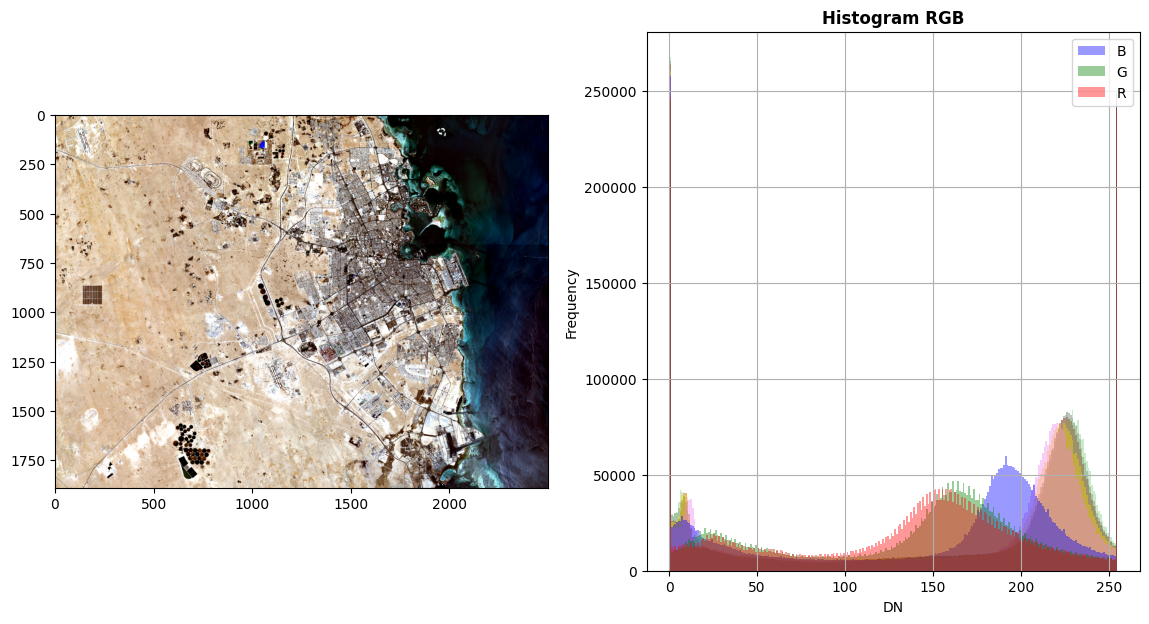

In [288]:
# 2025 high contrast
bands_8bit = []
for band in bands_2025[:8]:
    band = band.astype(np.float32)
    p1, p2 = np.percentile(band, (5,95))
    band = np.clip(band, p1, p2)
    band_8bit = (((band - p1))/(p2-p1))*255
    band_8bit = band_8bit.astype(np.uint8)
    bands_8bit.append(band_8bit)

bands_8bit_2025 = np.stack(bands_8bit, axis=0)
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(bands_8bit_2025[(3,2,1), :, :], ax=axrgb)
show_hist(bands_8bit_2025, bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)
plt.show()

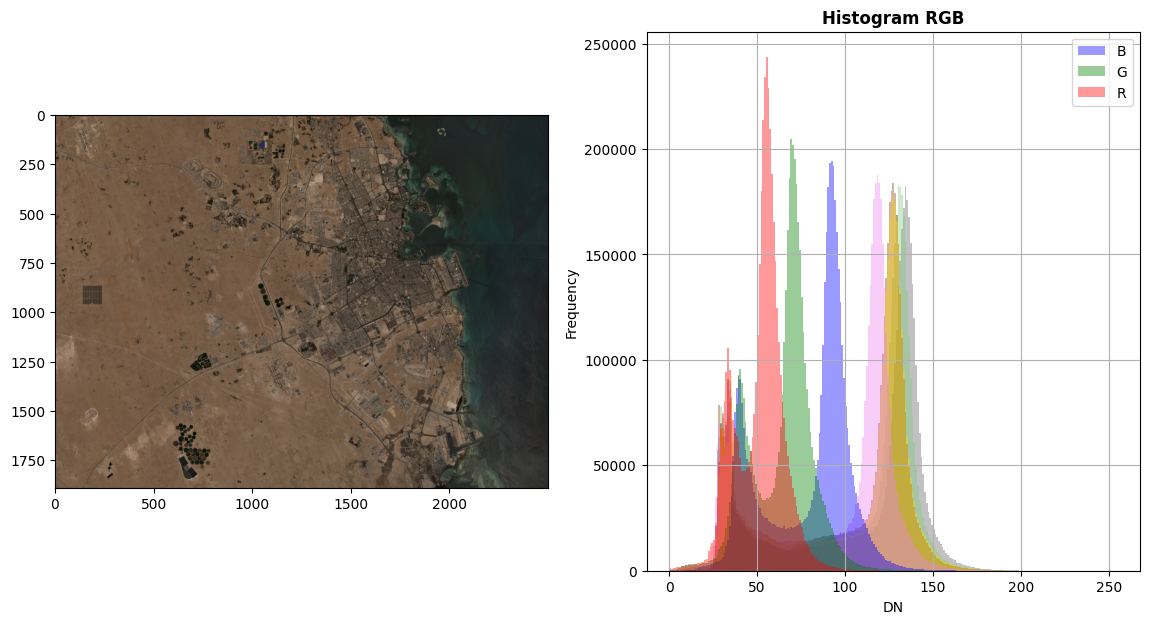

In [289]:
# 2025 normal

bands_8bit = []
for band in bands_2025[:8]:
    band = band.astype(np.float32)
    band = band/65535.0 * 255
    bands_8bit.append(band.astype(np.uint8))

bands_8bit_2025_N = np.stack(bands_8bit, axis=0)
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(bands_8bit_2025_N[(3,2,1), :, :], ax=axrgb)
show_hist(bands_8bit_2025_N, bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)
plt.show()

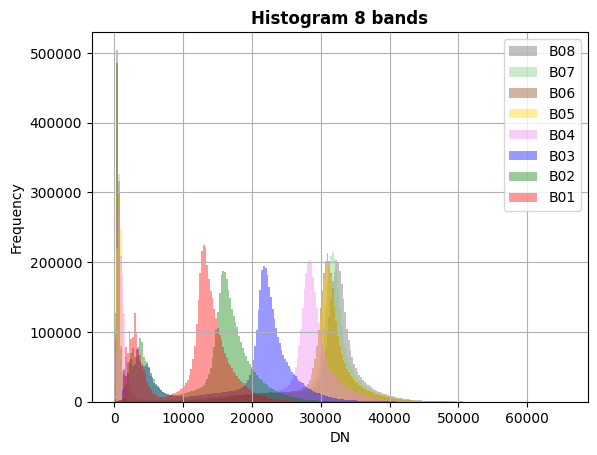

In [281]:
# Many low value pixels because the sea is very dark
show_hist(bands_2016[:8], bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram 8 bands', label = ['B01','B02','B03', 'B04', 'B05', 'B06', 'B07', 'B08'])

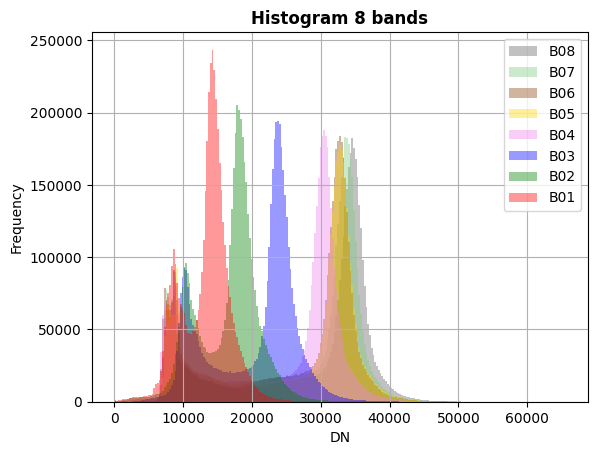

In [7]:
show_hist(bands_2025[:8], bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram 8 bands', label = ['B01','B02','B03', 'B04', 'B05', 'B06', 'B07', 'B08'])

Separate urban area for year 2016

In [ ]:
# Good for water detection, bad for urban areas
ndvi_index_2016 = ((bands_2016[7].astype(np.float32) - bands_2016[3].astype(np.float32))/(bands_2016[7].astype(np.float32) + bands_2016[3].astype(np.float32))).astype(np.float32)

C:\Users\Janek\AppData\Local\Temp\ipykernel_21852\288827256.py:2: RuntimeWarning: invalid value encountered in divide
  ndvi_index_2016 = ((bands_2016[7].astype(np.float32) - bands_2016[3].astype(np.float32))/(bands_2016[7].astype(np.float32) + bands_2016[3].astype(np.float32))).astype(np.float32)


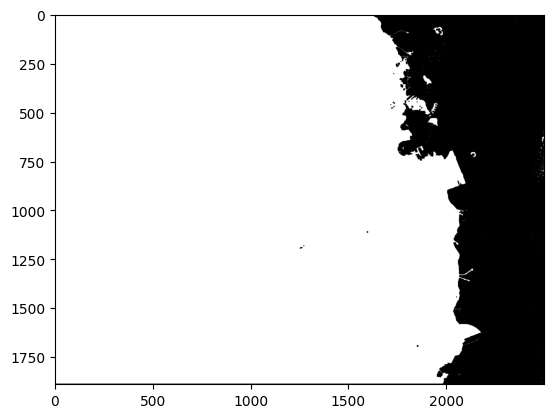

In [ ]:
water = ndvi_index_2016.copy()

water = np.where(water < 0, 0, 1)

water = binary_dilation(water, iterations=1, structure=np.ones((5,5)))
water_mask = binary_erosion(water, iterations=1, structure=np.ones((5,5)))

plt.imshow(water_mask, cmap='gray', vmin=0, vmax=1)
plt.show()

In [162]:
print(np.max(bands_2016))
PISI_2016 = bands_2016[1].astype('float32') / 65535.0*0.8192 - 0.5735*bands_2016[7].astype('float32') / 65535.0 + 0.0750

65535


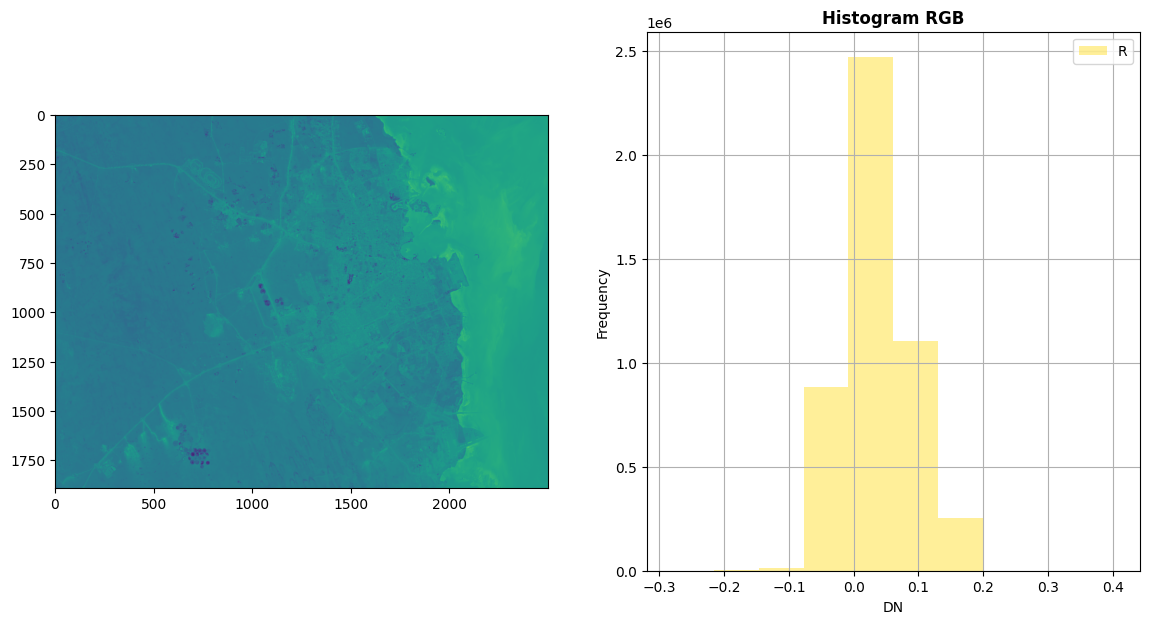

In [163]:
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(PISI_2016, ax=axrgb)
show_hist(PISI_2016, bins=10, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)

-0.28517097 0.4072706
0.4072706


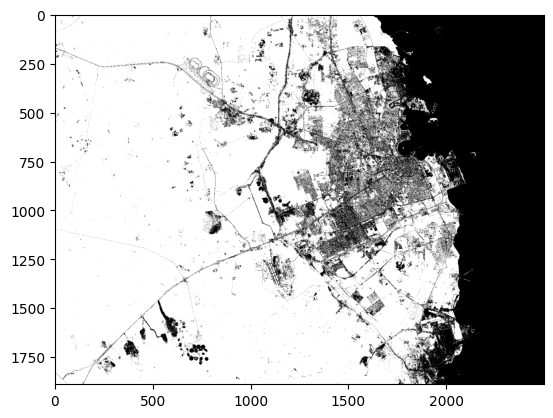

In [ ]:
print(np.min(PISI_2016), np.max(PISI_2016))
min_threshold = -0.05
max_threshold = 0.05
print(np.max(PISI_2016))

urban_mask = np.where((PISI_2016 >= min_threshold) & (PISI_2016 <= max_threshold), 1, 0)

fig, axrgb = plt.subplots(1, 1)
axrgb.imshow(urban_mask, cmap='gray', vmin=0, vmax=1)
plt.show()

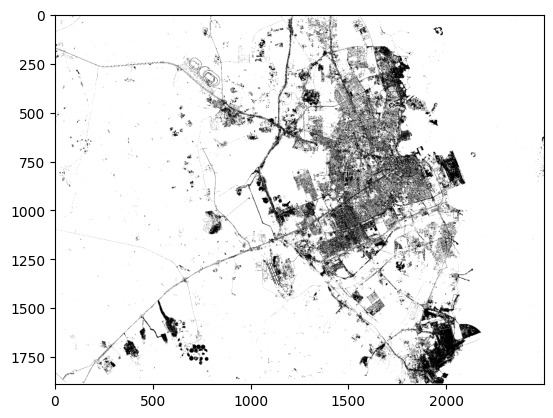

In [179]:
city_2016 = 1 - (water_mask - urban_mask)

fig, axrgb = plt.subplots(1, 1)
axrgb.imshow(city_2016, cmap='gray', vmin=0, vmax=1)

2025

C:\Users\Janek\AppData\Local\Temp\ipykernel_21852\1752119994.py:1: RuntimeWarning: invalid value encountered in divide
  ndvi_index_2025 = ((bands_2025[7].astype(np.float32) - bands_2025[3].astype(np.float32))/(bands_2025[7].astype(np.float32) + bands_2025[3].astype(np.float32))).astype(np.float32)


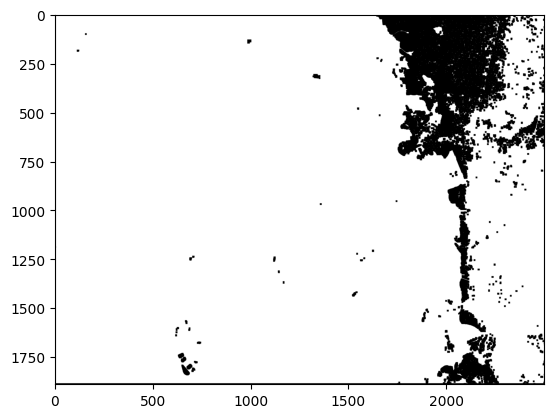

In [277]:
ndvi_index_2025 = ((bands_2025[7].astype(np.float32) - bands_2025[3].astype(np.float32))/(bands_2025[7].astype(np.float32) + bands_2025[3].astype(np.float32))).astype(np.float32)

water = ndvi_index_2025.copy()

#water = np.where(water < 0.02, 0, 1)

min_threshold = -0.05
max_threshold = 0.05
#water = np.where((water >= min_threshold) & (water <= max_threshold), 0, 1)
water = np.where(water < 0.05, 0, 1)

water = binary_dilation(water, iterations=2, structure=np.ones((5,5)))
water_mask = binary_erosion(water, iterations=2, structure=np.ones((5,5)))

plt.imshow(water_mask, cmap='gray', vmin=0, vmax=1)
plt.show()

0.53704983
-0.31327516


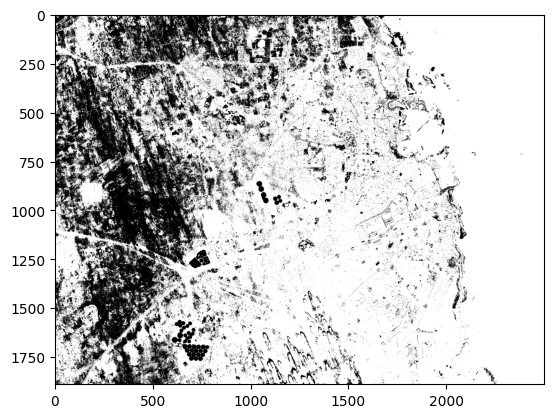

In [253]:
PISI_2025 = bands_2025[1].astype('float32') / 65535.0*0.8192 - 0.5735*bands_2025[7].astype('float32') / 65535.0 + 0.0750 

min_threshold = -0.0
max_threshold = 0.1
print(np.max(PISI_2025))
print(np.min(PISI_2025))
urban_mask = np.where((PISI_2025 >= min_threshold) & (PISI_2025 <= max_threshold), 1, 0)
urban_mask = np.where((PISI_2025 >= 0.0) & (PISI_2025 <= 0.2), 1, 0)

fig, axrgb = plt.subplots(1, 1)
city_2025 = urban_mask
axrgb.imshow(urban_mask, cmap='gray', vmin=0, vmax=1)
plt.show()

118.82181
-99.711716


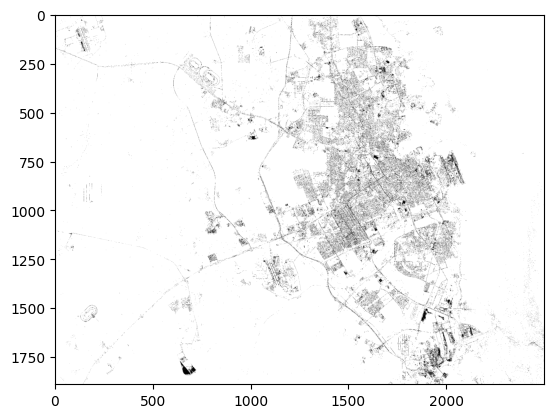

In [280]:
PISI_2025 = bands_2025[1].astype('float32') / 255.0*0.8192 - 0.5735*bands_2025[7].astype('float32') / 255.0 + 0.0750 

min_threshold = 0.2
max_threshold = 6
print(np.max(PISI_2025))
print(np.min(PISI_2025))
urban_mask = np.where((PISI_2025 >= min_threshold) & (PISI_2025 <= max_threshold), 0, 1)
# urban_mask = np.where((PISI_2025 >= 0.0) & (PISI_2025 <= 0.2), 1, 0)

fig, axrgb = plt.subplots(1, 1)
city_2025 = urban_mask
axrgb.imshow(urban_mask, cmap='gray', vmin=0, vmax=1)
plt.show()

Comparison

<Axes: >

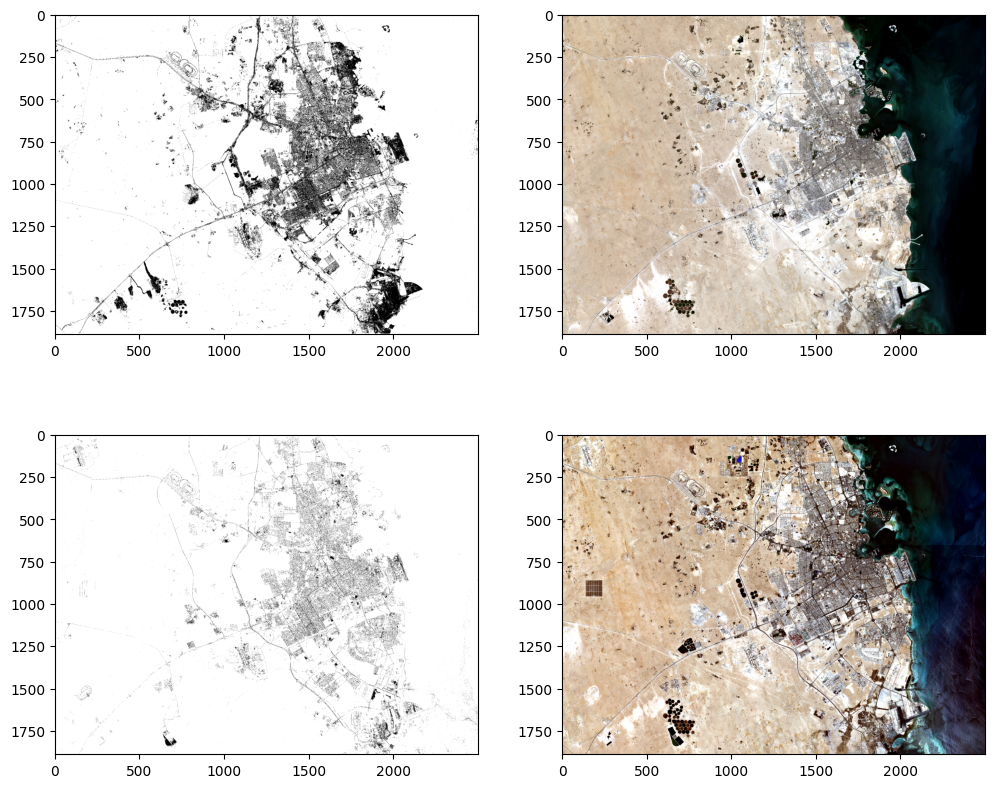

In [291]:
fig, ax = plt.subplots(2,2,figsize=(12,10))
ax[0][0].imshow(city_2016, cmap='gray', vmin=0, vmax=1)
show(bands_8bit_2016[(3,2,1), :, :], ax=ax[0][1])
# ax[0][1].imshow(bands_8bit_2016[(3,2,1), :, :], vmin=0, vmax=255)

ax[1][0].imshow(city_2025, cmap='gray', vmin=0, vmax=1)
show(bands_8bit_2025[(3,2,1), :, :], ax=ax[1][1])

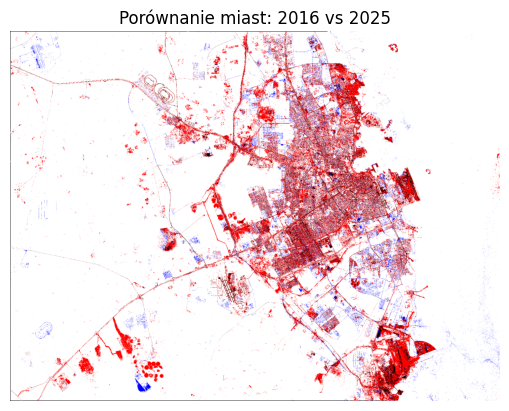

In [293]:
h, w = city_2016.shape
comparison = np.zeros((h, w, 3), dtype=np.uint8)

# Przypadki:
both_city = (city_2016 == 1) & (city_2025 == 1)
only_2016 = (city_2016 == 0) & (city_2025 == 1)
only_2025 = (city_2016 == 1) & (city_2025 == 0)
neither = (city_2016 == 0) & (city_2025 == 0)

# Przypisz kolory
comparison[both_city]   = [255, 255, 255]  # biały
comparison[only_2016]   = [255, 0, 0]      # czerwony
comparison[only_2025]   = [0, 0, 255]      # niebieski
comparison[neither]     = [0, 0, 0]        # czarny

# Wyświetl
plt.imshow(comparison)
plt.title("Porównanie miast: 2016 vs 2025")
plt.axis('off')
plt.show()

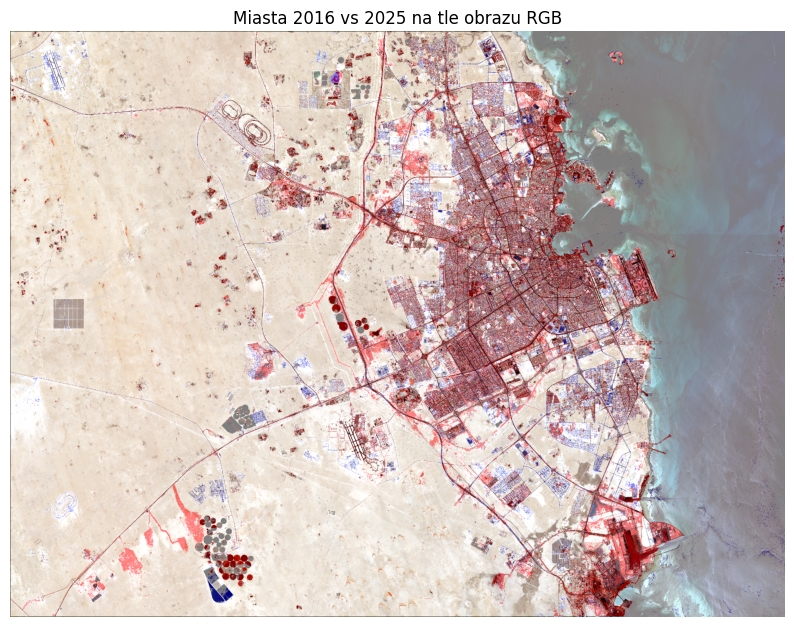

In [294]:
rgb = np.transpose(bands_8bit_2025[(3,2,1), :, :], (1, 2, 0))  # Shape: (H, W, 3)
mask_overlay = comparison

fig, ax = plt.subplots(figsize=(10,10))

# Pokaż tło RGB (bazowy obraz)
ax.imshow(rgb)

# Nałóż maskę z przezroczystością (alpha 0.5 = 50%)
ax.imshow(mask_overlay, alpha=0.5)

ax.set_title("Miasta 2016 vs 2025 na tle obrazu RGB")
ax.axis('off')
plt.show()